# Introduction to Neural Networks and Deep Learning

## Brief history

### Early neural networks (1943–1997)

| Year | Milestone | Significance |
|------|-----------|-------------|
| 1943 | McCulloch & Pitts | First mathematical model of a neuron |
| 1958 | Rosenblatt's Perceptron | First implemented neural network |
| 1969 | Minsky & Papert's *Perceptrons* | Demonstrated limitations → first "AI winter" |
| 1986 | Backpropagation (Hinton et al.) | Enabled training multilayer networks |
| 1988 | LeNet (LeCun) | First CNN for handwritten digit recognition |
| 1997 | LSTM (Hochreiter & Schmidhuber) | Solved vanishing gradients for sequences |

### The deep learning revolution (2012–present)

**Enabling factors:**
- GPU computing power (NVIDIA CUDA)
- Big Data availability (ImageNet, Common Crawl)
- Algorithmic advances (Dropout, BatchNorm, Adam)
- Massive investment from tech industry

| Year | Event | Impact |
|------|-------|--------|
| 2012 | **AlexNet** | 15.3% error on ImageNet (vs. 26%) — sparked the DL boom |
| 2014 | **GANs** (Goodfellow) | Generative modeling revolution |
| 2015 | **ResNet** | Residual connections enabled 100+ layer networks |
| 2016 | **AlphaGo** | Beat world Go champion Lee Sedol |
| 2017 | **Transformer** | "Attention is All You Need" — the architecture behind ChatGPT |
| 2018 | **BERT** | Bidirectional language understanding |
| 2020 | **GPT-3** | Emergent capabilities in large language models |
| 2022 | **ChatGPT** | Mainstream conversational AI |
| 2024 | **o1** (OpenAI) | Advanced reasoning capabilities |
| 2025 | **DeepSeek-R1** | Open-weights model matching o1 performance |

> Every major breakthrough above relied on neural networks. The rest of this notebook explains what they are and how they learn.

## What is a neural network?

A neural network is a function that learns from examples. At its core is a simple building block: the **perceptron** (artificial neuron).

> [3Blue1Brown — But what is a neural network?](https://www.youtube.com/watch?v=aircAruvnKk)

### The perceptron

![Perceptron diagram](img/perceptron.png)

A perceptron takes numbers in, computes a weighted sum, and applies a simple rule:

$$\hat{y} = f\!\left(\sum_{i=1}^{n} w_i x_i + b\right)$$

Think of it as a **weighted vote**:
1. **Inputs** ($x_i$): your features (e.g., pixel intensities, sensor readings)
2. **Weights** ($w_i$): how much the model "cares" about each feature
3. **Bias** ($b$): the baseline output when all inputs are zero
4. **Activation** ($f$): a non-linear function that shapes the output

**Key insight:** without an activation function (i.e., $f(x) = x$), a single perceptron is exactly equivalent to **linear regression**. (Later we will see how adding specific activations turns it into models like **logistic regression**).

## Linear separability and the XOR problem

A perceptron draws a single straight decision boundary. If your classes can be separated by one line (in 2D) or hyperplane (in higher dimensions), the perceptron works. If not — it fails.

![AND, OR, and XOR](img/xor_and_or_scatter.png)

| Gate | Linearly separable? | Perceptron solves it? |
|------|--------------------:|----------------------:|
| AND  | ✓ Yes | ✓ |
| OR   | ✓ Yes | ✓ |
| XOR  | ✗ No  | ✗ |

**Why does XOR matter?** It's the simplest example of a problem where you need *combinations of conditions* ("A or B, but not both"). In real data, this appears as feature interactions — fraud detection ("high amount AND new device"), medical diagnosis, etc. A single boundary can't capture these patterns.

> **Deep dive:** see [complementary/xor_linearity.ipynb](complementary/xor_linearity.ipynb) for a full interactive exploration with decision boundary visualizations.

## Multilayer perceptrons (MLPs)

To solve problems like XOR, we stack perceptrons into layers:

![MLP Architecture](img/mlp_diagram.png)

Each hidden layer learns **intermediate representations** — features that a single perceptron can't capture:

![Feature hierarchy](img/feature_hierarchy.png)

**Critical detail:** stacking linear layers *without* activations between them collapses back to a single linear transformation. You need repeated blocks of:

1. **Linear layer** → learns a weighted combination
2. **Activation function** → bends the output non-linearly

This is what makes neural networks more powerful than linear models.

## Activation functions

Activation functions are the key to a neural network's power. Without them, no matter how many layers you stack, the entire network mathematically collapses into a single linear transformation (a "big linear model"), making it impossible to solve complex, non-linear problems like XOR. By introducing **non-linearity** after each linear layer, activation functions allow the network to bend and fold the feature space to learn highly complex patterns.

| Function | Formula (programmer view) | Output range | Typical use |
|----------|--------------------------|:------------:|-------------|
| **ReLU** | `max(0, x)` | $[0, \infty)$ | Default for hidden layers |
| **Leaky ReLU** | `x if x > 0 else 0.1*x` | $(-\infty, \infty)$ | When you want to avoid "dead" neurons |
| **Sigmoid** | $\frac{1}{1 + e^{-x}}$ | $(0, 1)$ | Binary classification output |
| **Tanh** | $\frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $(-1, 1)$ | Some legacy architectures |
| **Softmax** | scores → probability distribution | sums to 1 | Multi-class output |

**Rules of thumb:**
- Use **ReLU** in hidden layers unless you have a reason not to
- Use **sigmoid** for binary outputs, **softmax** for multi-class outputs
- The output activation is part of your model's "API contract" — it shapes what the numbers mean

The following plot lets you compare these functions side by side. Notice how ReLU is the simplest (just zero out negatives), while sigmoid and tanh "squeeze" all values into a bounded range:

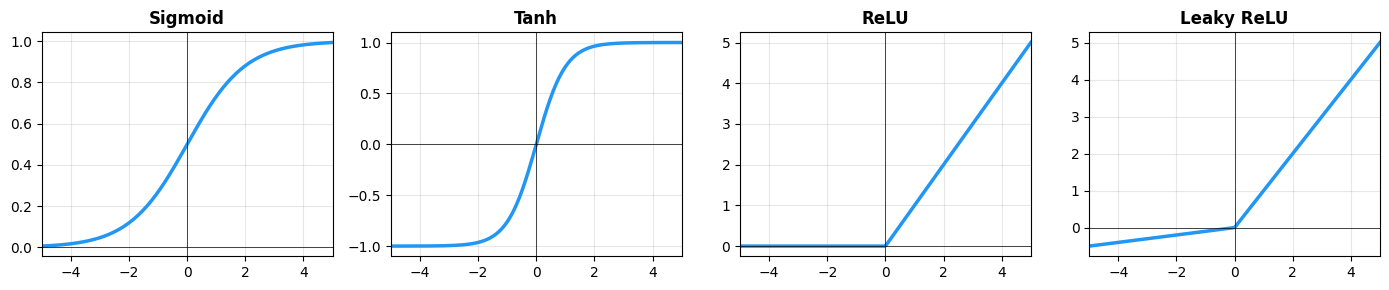

In [ ]:
import torch
import matplotlib.pyplot as plt

x = torch.linspace(-5, 5, 200)

activations = [
    ("Sigmoid", torch.sigmoid(x)),
    ("Tanh", torch.tanh(x)),
    ("ReLU", torch.relu(x)),
    ("Leaky ReLU", torch.nn.functional.leaky_relu(x, 0.1)),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (name, y) in zip(axes, activations):
    ax.plot(x.numpy(), y.numpy(), linewidth=2.5, color="#2196F3")
    ax.axhline(y=0, color="k", linewidth=0.5)
    ax.axvline(x=0, color="k", linewidth=0.5)
    ax.set_title(name, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 5)
plt.tight_layout()
plt.show()

## Training overview

Training a neural network means **adjusting the weights so predictions match the targets**.

> [3Blue1Brown — Gradient descent, how neural networks learn](https://www.youtube.com/watch?v=IHZwWFHWa-w)

### Loss: "how wrong is the model?"

A **loss function** assigns a number to "how bad the predictions are." Lower is better.

| Task | Common loss | What it measures |
|------|-------------|-----------------|
| Regression | MSE (Mean Squared Error) | Average squared distance from target |
| Binary classification | Binary Cross-Entropy | How far predicted probabilities are from 0/1 |
| Multi-class classification | Cross-Entropy | How far predicted distribution is from true label |

### Gradient descent: "walk downhill"

Gradient descent is an optimization algorithm: it iteratively adjusts parameters in the direction that reduces the loss the most.

![Gradient descent on a loss surface](img/gradient_descent_surface.png)

The **learning rate** controls step size: too large → unstable, too small → slow.

| Variant | Uses | Pros | Cons |
|---------|------|------|------|
| Batch GD | All training data | Stable gradients | Slow, high memory |
| Stochastic GD | 1 sample at a time | Fast updates | Very noisy |
| **Mini-batch GD** | Small batch (32–256) | Best of both worlds | Standard in practice |

> **Deep dive:** see [complementary/gradient_descent_from_scratch.ipynb](complementary/gradient_descent_from_scratch.ipynb) for a from-scratch numpy implementation with 3D cost landscape visualizations.

### Backpropagation: "pass the blame back"

> [3Blue1Brown — Backpropagation](https://www.youtube.com/watch?v=Ilg3gGewQ5U)

**Backpropagation** computes "which weights should change, and by how much" to reduce the loss.

You don't need to do derivatives by hand. The mental model:
1. **Forward pass** builds a computation graph (chain of tensor operations)
2. `loss.backward()` walks the graph **backwards**, computing gradients for every parameter
3. **Optimizer** (SGD, Adam, …) uses those gradients to update parameters

This is what PyTorch's **autograd** does automatically.

### The core training loop

In PyTorch, training always follows this pattern:

```python
for epoch in range(num_epochs):
    # 1. Forward pass
    predictions = model(inputs)
    
    # 2. Compute loss
    loss = loss_fn(predictions, targets)
    
    # 3. Zero gradients (reset from previous step)
    optimizer.zero_grad()
    
    # 4. Backward pass (compute gradients)
    loss.backward()
    
    # 5. Update parameters
    optimizer.step()
```

Two important modes:
- `model.train()` — enables dropout, batch norm updates (use during training)
- `model.eval()` + `torch.no_grad()` — disables gradients (use during inference, faster)

## Deep learning architectures (preview)

The MLP we've described is just one type of neural network. Modern deep learning uses specialized architectures for different data types:

| Architecture | Specialized for | Key innovation | Real-world example |
|--------------|----------------|----------------|-------------------|
| **MLP** | Tabular data | Universal approximation | Credit scoring |
| **CNN** | Images | Spatial feature learning | Medical imaging, self-driving |
| **RNN / LSTM** | Sequences | Temporal memory | Speech recognition |
| **Transformer** | Any sequence | Self-attention, parallelization | ChatGPT, translation |
| **GAN** | Generation | Adversarial training | Image synthesis |
| **Autoencoder** | Compression | Reconstruction learning | Anomaly detection |

Each will be covered in detail in later notebooks. This course focuses on the **fundamentals that all of them share**: neurons, layers, activations, loss functions, gradient descent, and backpropagation.

## Resources (highly recommended)

**Video series:**
- [3Blue1Brown — Neural Networks](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) — visual, intuitive explanations (English)
- [DotCSV — Neural Networks](https://www.youtube.com/playlist?list=PL-Ogd76BhmcC_E2RjgIIJZd1DQdYHcVf0) — excellent series (Spanish)
- [ChatGPT is made from 100 million of these [The Perceptron]](https://www.youtube.com/watch?v=l-9ALe3U-Fg) — (English)

**Interactive:**
- [TensorFlow Playground](https://playground.tensorflow.org/) — experiment with neural networks in your browser following [the provided guide](complementary/tf_playground_guide.ipynb) and study the excelent article "[Understanding neural networks with TensorFlow Playground](https://cloud.google.com/blog/products/ai-machine-learning/understanding-neural-networks-with-tensorflow-playground)".